# Audio Anomaly Detection Pipeline
## Demonstration for Industrial Predictive Maintenance

End-to-end pipeline simulating the detection of OHT machine 
degradation from multimodal sensor data.

**Pipeline:**
Raw Audio → Spectrogram → MFCCs → Feature Extraction → 
Multimodal Fusion → Autoencoder Anomaly Detection → 
Temporal Drift Validation

**Key Results:**
- Autoencoder: 0/40 false alarms, 10/10 anomalies caught
- Multimodal features: 2.4× better separation than audio alone
- Temporal drift: degradation detectable weeks before failure

In [28]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load sample audio
y, sr = librosa.load(librosa.ex('trumpet'))
print(f'Duration: {len(y)/sr:.2f} seconds')
print(f'Sample rate: {sr} Hz')
print(f'Total samples: {len(y)}')
print(f'Data type: {y.dtype}')

Duration: 5.33 seconds
Sample rate: 22050 Hz
Total samples: 117601
Data type: float32


## Section 1 — Audio Pipeline

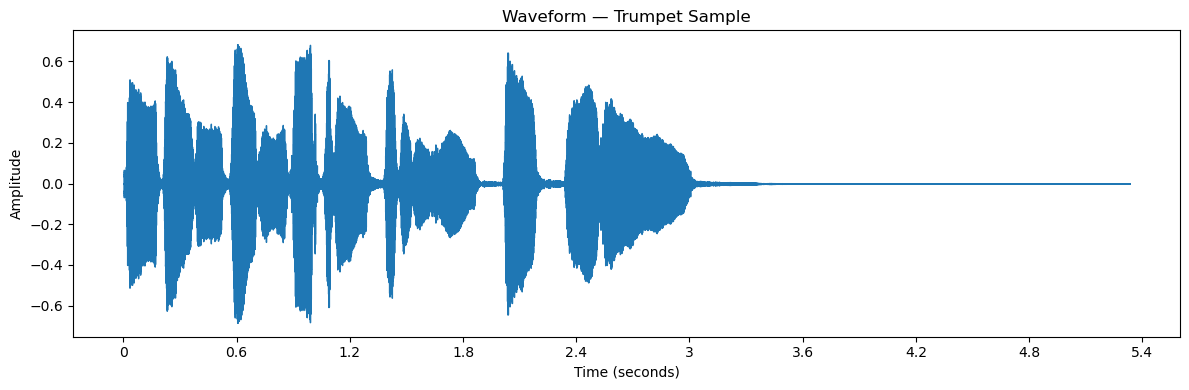

In [29]:
# Visualise the waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform — Trumpet Sample')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

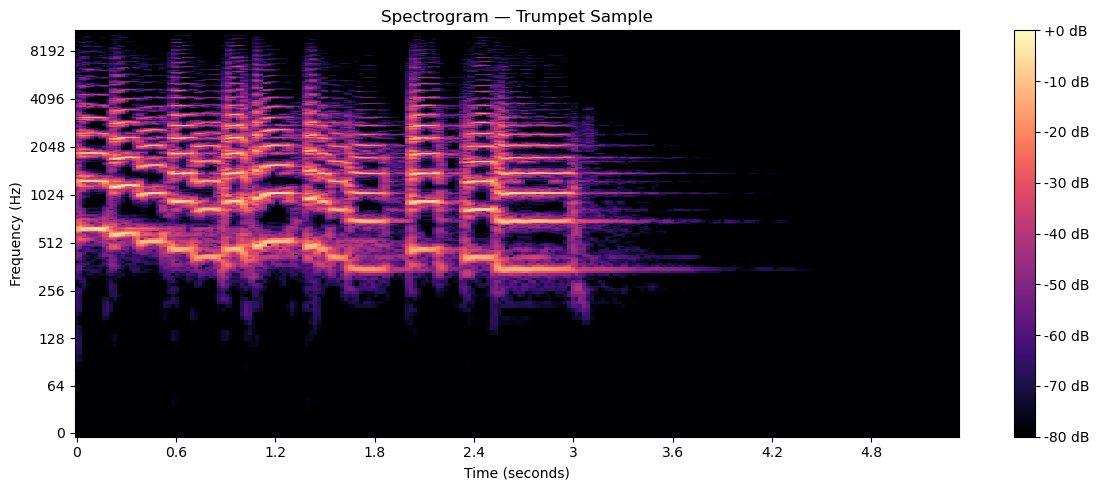

Spectrogram shape: (1025, 230)


In [30]:
# Compute and plot spectrogram
D = librosa.stft(y)  # Short Time Fourier Transform
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram — Trumpet Sample')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

print(f'Spectrogram shape: {D_db.shape}')

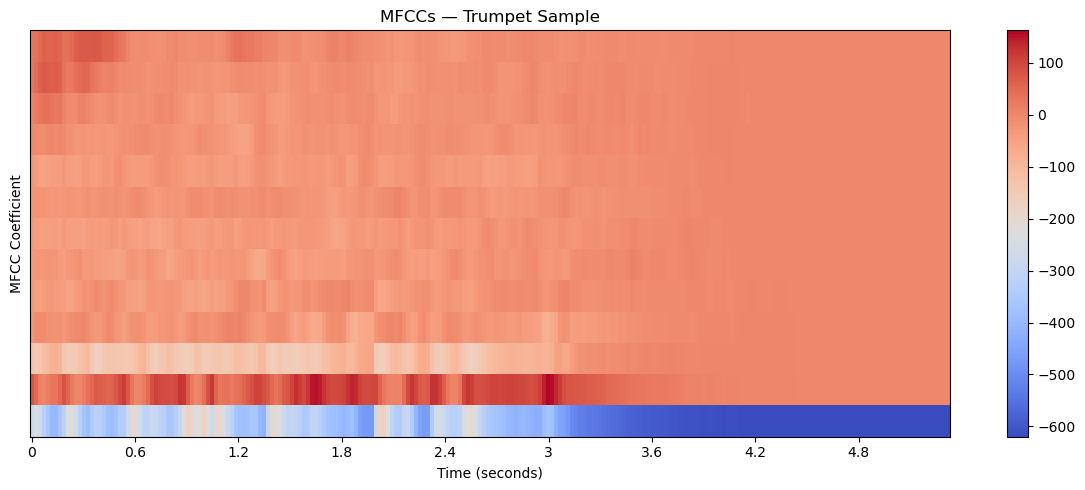

MFCC shape: (13, 230)
Min value: -619.71
Max value: 162.11


In [31]:
# Extract MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('MFCCs — Trumpet Sample')
plt.xlabel('Time (seconds)')
plt.ylabel('MFCC Coefficient')
plt.tight_layout()
plt.show()

print(f'MFCC shape: {mfccs.shape}')
print(f'Min value: {mfccs.min():.2f}')
print(f'Max value: {mfccs.max():.2f}')

In [32]:
# Summarise MFCCs into a feature vector
mfcc_mean = np.mean(mfccs, axis=1)
mfcc_std  = np.std(mfccs, axis=1)

# Combine into one feature vector
feature_vector = np.concatenate([mfcc_mean, mfcc_std])

print(f'MFCC means shape: {mfcc_mean.shape}')
print(f'MFCC stds shape:  {mfcc_std.shape}')
print(f'Feature vector shape: {feature_vector.shape}')
print(f'\nMFCC means:\n{mfcc_mean.round(2)}')
print(f'\nMFCC stds:\n{mfcc_std.round(2)}')

MFCC means shape: (13,)
MFCC stds shape:  (13,)
Feature vector shape: (26,)

MFCC means:
[-4.4226e+02  5.0380e+01 -7.0580e+01 -1.8440e+01 -1.6290e+01 -1.8830e+01
 -2.1320e+01 -1.3630e+01 -2.0640e+01 -1.2660e+01 -9.4600e+00 -4.9700e+00
  4.0000e-01]

MFCC stds:
[148.18  45.6   61.96  19.52  17.12  17.46  17.43  11.28  16.5   11.81
  13.68  17.99  21.54]


## Section 2 — Anomaly Detection

In [33]:
from sklearn.ensemble import IsolationForest
import numpy as np

np.random.seed(42)
n_recordings = 50

feature_matrix = []

for i in range(n_recordings):
    # Small noise = normal, large noise = abnormal
    noise_level = 0.01 if i < 40 else 0.15
    y_noisy = y + np.random.normal(0, noise_level, len(y))
    
    # Extract MFCCs
    mfccs_i = librosa.feature.mfcc(y=y_noisy, sr=sr, n_mfcc=13)
    
    # Feature vector
    means = np.mean(mfccs_i, axis=1)
    stds  = np.std(mfccs_i, axis=1)
    features = np.concatenate([means, stds])
    feature_matrix.append(features)

feature_matrix = np.array(feature_matrix)
print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'First 40 = normal recordings')
print(f'Last 10  = abnormal recordings (higher noise)')

Feature matrix shape: (50, 26)
First 40 = normal recordings
Last 10  = abnormal recordings (higher noise)


In [34]:
# Train Isolation Forest on NORMAL data only (first 40 recordings)
normal_data   = feature_matrix[:40]   # recordings 0-39
abnormal_data = feature_matrix[40:]   # recordings 40-49

# Train only on normal
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(normal_data)

# Score ALL 50 recordings
# Lower score = more anomalous
scores = model.decision_function(feature_matrix)
predictions = model.predict(feature_matrix)
# -1 = anomaly, 1 = normal

print(f'Normal data shape:   {normal_data.shape}')
print(f'Abnormal data shape: {abnormal_data.shape}')
print(f'\nPredictions:')
print(f'Normal recordings   (0-39): {predictions[:40].tolist()}')
print(f'Abnormal recordings (40-49): {predictions[40:].tolist()}')

Normal data shape:   (40, 26)
Abnormal data shape: (10, 26)

Predictions:
Normal recordings   (0-39): [1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Abnormal recordings (40-49): [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]


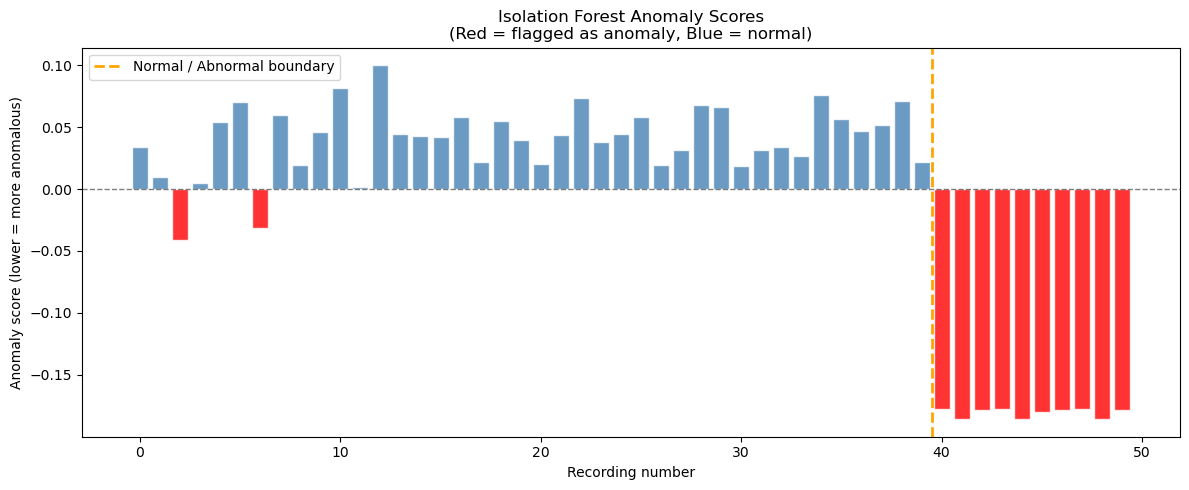


Score summary:
Normal recordings   — mean score: 0.0402
Abnormal recordings — mean score: -0.1804


In [35]:
# Visualise anomaly scores
plt.figure(figsize=(12, 5))

colors = ['red' if p == -1 else 'steelblue' for p in predictions]
plt.bar(range(50), scores, color=colors, alpha=0.8, edgecolor='white')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=39.5, color='orange', linestyle='--', linewidth=2, label='Normal / Abnormal boundary')

plt.xlabel('Recording number')
plt.ylabel('Anomaly score (lower = more anomalous)')
plt.title('Isolation Forest Anomaly Scores\n(Red = flagged as anomaly, Blue = normal)')
plt.legend()
plt.tight_layout()
plt.show()

print('\nScore summary:')
print(f'Normal recordings   — mean score: {scores[:40].mean():.4f}')
print(f'Abnormal recordings — mean score: {scores[40:].mean():.4f}')


In [36]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Step 1 — Scale the features
# Neural networks work much better when features are on the same scale
scaler = StandardScaler()
normal_scaled   = scaler.fit_transform(normal_data)
all_scaled      = scaler.transform(feature_matrix)

print(f'Normal data scaled shape: {normal_scaled.shape}')
print(f'Mean after scaling: {normal_scaled.mean():.4f} (should be ~0)')
print(f'Std after scaling:  {normal_scaled.std():.4f}  (should be ~1)')

Normal data scaled shape: (40, 26)
Mean after scaling: 0.0000 (should be ~0)
Std after scaling:  1.0000  (should be ~1)


In [37]:
# Step 2 — Build and train the autoencoder
# Input(26) → Encoder(16) → Bottleneck(8) → Decoder(16) → Output(26)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 8, 16),  # compress to 8 then expand back
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False
)

# Train only on normal data — this is the key
autoencoder.fit(normal_scaled, normal_scaled)  # input = output

print('Autoencoder trained successfully!')
print(f'Architecture: 26 → 16 → 8 → 16 → 26')
print(f'Training iterations: {autoencoder.n_iter_}')
print(f'Final training loss: {autoencoder.loss_:.6f}')

Autoencoder trained successfully!
Architecture: 26 → 16 → 8 → 16 → 26
Training iterations: 500
Final training loss: 0.152514


C:\Users\umadv\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [38]:
# Step 3 — Compute reconstruction error for all 50 recordings
reconstructed = autoencoder.predict(all_scaled)

# Reconstruction error = mean squared difference between 
# original and reconstructed
reconstruction_error = np.mean((all_scaled - reconstructed)**2, axis=1)

print('Reconstruction errors:')
print(f'Normal recordings   (0-39) — mean error: {reconstruction_error[:40].mean():.4f}')
print(f'Abnormal recordings (40-49) — mean error: {reconstruction_error[40:].mean():.4f}')
print(f'\nIndividual errors:')
print(f'Normal   : {reconstruction_error[:40].round(3).tolist()}')
print(f'Abnormal : {reconstruction_error[40:].round(3).tolist()}')

Reconstruction errors:
Normal recordings   (0-39) — mean error: 0.3043
Abnormal recordings (40-49) — mean error: 29643.0318

Individual errors:
Normal   : [0.369, 0.155, 0.899, 0.304, 0.104, 0.241, 0.368, 0.181, 0.453, 0.294, 0.328, 0.113, 0.183, 0.174, 0.475, 0.311, 0.198, 0.263, 0.299, 0.298, 0.388, 0.18, 0.285, 0.267, 0.32, 0.411, 0.292, 0.494, 0.306, 0.236, 0.293, 0.534, 0.35, 0.133, 0.319, 0.569, 0.266, 0.108, 0.216, 0.194]
Abnormal : [29763.121, 29541.046, 29624.127, 29613.024, 29620.843, 29606.311, 29768.821, 29716.751, 29631.957, 29544.315]


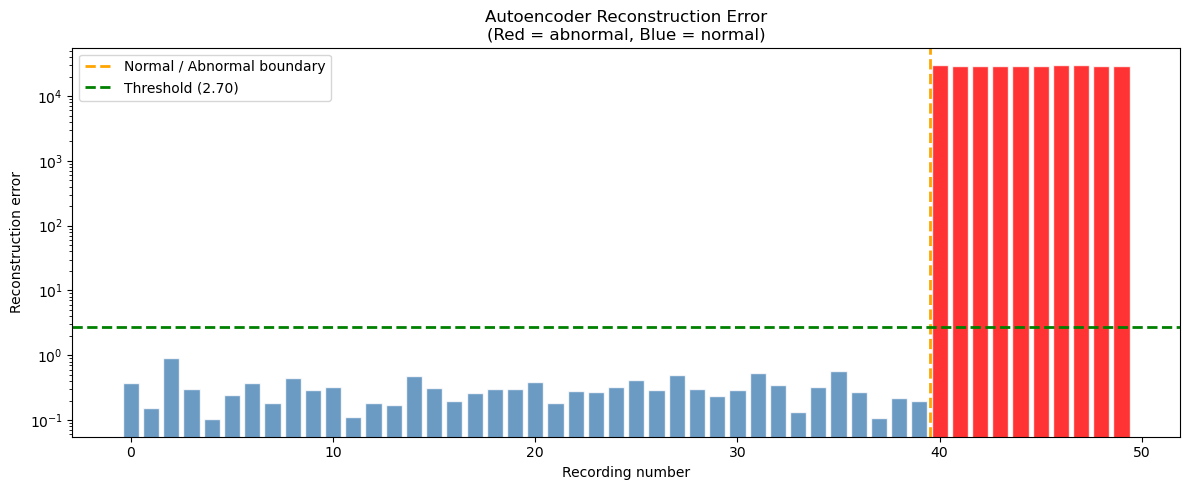

Threshold set at: 2.70

Normal recordings flagged as anomaly:   0/40
Abnormal recordings caught as anomaly:  10/10


In [39]:
# Visualise reconstruction errors
plt.figure(figsize=(12, 5))

colors = ['red' if i >= 40 else 'steelblue' for i in range(50)]
plt.bar(range(50), reconstruction_error, color=colors, alpha=0.8, edgecolor='white')

plt.axvline(x=39.5, color='orange', linestyle='--', 
            linewidth=2, label='Normal / Abnormal boundary')

# Set threshold at 3x the max normal error
threshold = reconstruction_error[:40].max() * 3
plt.axhline(y=threshold, color='green', linestyle='--', 
            linewidth=2, label=f'Threshold ({threshold:.2f})')

plt.xlabel('Recording number')
plt.ylabel('Reconstruction error')
plt.title('Autoencoder Reconstruction Error\n(Red = abnormal, Blue = normal)')
plt.legend()
plt.yscale('log')  # log scale so we can see normal recordings too
plt.tight_layout()
plt.show()

# Apply threshold
ae_predictions = (reconstruction_error > threshold).astype(int)
print(f'Threshold set at: {threshold:.2f}')
print(f'\nNormal recordings flagged as anomaly:   {ae_predictions[:40].sum()}/40')
print(f'Abnormal recordings caught as anomaly:  {ae_predictions[40:].sum()}/10')

## Section 3 — Multimodal Feature Fusion

In [40]:
print("Section 3: Adding multimodal features")
print("="*55)
print("So far we have 26 audio features per recording.")
print("Now we add:")
print("  - velocity        (how fast the OHT was moving)")
print("  - acceleration    (was it speeding up or slowing down)")
print("  - days since maintenance  (how long since last service)")
print("="*55)

Section 3: Adding multimodal features
So far we have 26 audio features per recording.
Now we add:
  - velocity        (how fast the OHT was moving)
  - acceleration    (was it speeding up or slowing down)
  - days since maintenance  (how long since last service)


In [41]:
# Simulate multimodal features for all 50 recordings
np.random.seed(42)

# ── Velocity (m/s) ──
# Normal machines: consistent speed around 1.5 m/s
# Abnormal machines: slightly irregular speed
velocity_normal   = np.random.normal(1.5, 0.1, 40)   # mean=1.5, small variation
velocity_abnormal = np.random.normal(1.5, 0.4, 10)   # same mean, more erratic

velocity = np.concatenate([velocity_normal, velocity_abnormal])

# ── Acceleration (m/s²) ──
# Normal machines: smooth, close to zero (constant speed)
# Abnormal machines: more variation (jerky movement)
accel_normal   = np.random.normal(0.0, 0.05, 40)  # smooth
accel_abnormal = np.random.normal(0.0, 0.25, 10)  # jerky

acceleration = np.concatenate([accel_normal, accel_abnormal])

# ── Days since last maintenance ──
# Normal machines: recently serviced (0-30 days)
# Abnormal machines: overdue (60-120 days)
days_normal   = np.random.randint(0, 30, 40)
days_abnormal = np.random.randint(60, 120, 10)

days_since_maintenance = np.concatenate([days_normal, days_abnormal])

print(f'Velocity         — Normal: {velocity[:40].mean():.2f} m/s  | Abnormal: {velocity[40:].mean():.2f} m/s')
print(f'Acceleration     — Normal: {acceleration[:40].mean():.3f} m/s² | Abnormal: {acceleration[40:].mean():.3f} m/s²')
print(f'Days since maint — Normal: {days_since_maintenance[:40].mean():.1f} days | Abnormal: {days_since_maintenance[40:].mean():.1f} days')

Velocity         — Normal: 1.48 m/s  | Abnormal: 1.40 m/s
Acceleration     — Normal: 0.003 m/s² | Abnormal: -0.037 m/s²
Days since maint — Normal: 14.4 days | Abnormal: 89.9 days


In [42]:
# Combine audio features with multimodal features
# Reshape multimodal features to (50, 3)
multimodal_features = np.column_stack([
    velocity,
    acceleration,
    days_since_maintenance
])

# Combine with audio feature matrix
combined_matrix = np.concatenate([feature_matrix, multimodal_features], axis=1)

print(f'Audio features shape:      {feature_matrix.shape}')
print(f'Multimodal features shape: {multimodal_features.shape}')
print(f'Combined matrix shape:     {combined_matrix.shape}')
print(f'\nFeature breakdown:')
print(f'  MFCC means        : 13 features (cols 0-12)')
print(f'  MFCC stds         : 13 features (cols 13-25)')
print(f'  Velocity          : 1  feature  (col 26)')
print(f'  Acceleration      : 1  feature  (col 27)')
print(f'  Days since maint  : 1  feature  (col 28)')
print(f'  Total             : 29 features per recording')

Audio features shape:      (50, 26)
Multimodal features shape: (50, 3)
Combined matrix shape:     (50, 29)

Feature breakdown:
  MFCC means        : 13 features (cols 0-12)
  MFCC stds         : 13 features (cols 13-25)
  Velocity          : 1  feature  (col 26)
  Acceleration      : 1  feature  (col 27)
  Days since maint  : 1  feature  (col 28)
  Total             : 29 features per recording


In [43]:
# Train autoencoder on COMBINED features
# Normal data only — first 40 recordings
normal_combined   = combined_matrix[:40]
abnormal_combined = combined_matrix[40:]

# Scale combined features
scaler_combined = StandardScaler()
normal_combined_scaled = scaler_combined.fit_transform(normal_combined)
all_combined_scaled    = scaler_combined.transform(combined_matrix)

# Train autoencoder — bigger architecture for more features
autoencoder_combined = MLPRegressor(
    hidden_layer_sizes=(20, 8, 20),  # slightly bigger for 29 features
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    verbose=False
)

autoencoder_combined.fit(normal_combined_scaled, normal_combined_scaled)

# Reconstruction error
recon_combined = autoencoder_combined.predict(all_combined_scaled)
error_combined = np.mean((all_combined_scaled - recon_combined)**2, axis=1)

print(f'Combined model trained successfully!')
print(f'Architecture: 29 → 20 → 8 → 20 → 29')
print(f'\nReconstruction errors:')
print(f'Normal recordings   — mean error: {error_combined[:40].mean():.4f}')
print(f'Abnormal recordings — mean error: {error_combined[40:].mean():.4f}')
print(f'\nSeparation ratio: {error_combined[40:].mean() / error_combined[:40].mean():.0f}x')

Combined model trained successfully!
Architecture: 29 → 20 → 8 → 20 → 29

Reconstruction errors:
Normal recordings   — mean error: 0.1767
Abnormal recordings — mean error: 41549.8932

Separation ratio: 235082x


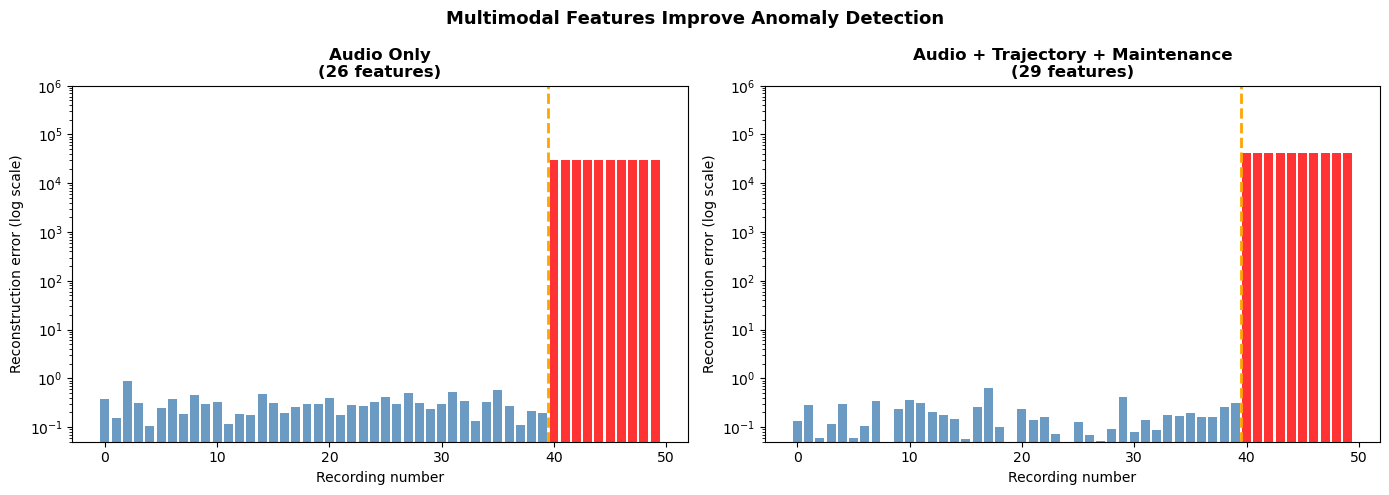

Audio only     separation: 97420x
Multimodal     separation: 235082x
Improvement from multimodal: 2.4x better separation


In [44]:
# Compare audio-only vs multimodal side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Audio only
colors = ['red' if i >= 40 else 'steelblue' for i in range(50)]
axes[0].bar(range(50), reconstruction_error, color=colors, alpha=0.8)
axes[0].axvline(x=39.5, color='orange', linestyle='--', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_title('Audio Only\n(26 features)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recording number')
axes[0].set_ylabel('Reconstruction error (log scale)')
axes[0].set_ylim(0.05, 10**6)

# Multimodal
axes[1].bar(range(50), error_combined, color=colors, alpha=0.8)
axes[1].axvline(x=39.5, color='orange', linestyle='--', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('Audio + Trajectory + Maintenance\n(29 features)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recording number')
axes[1].set_ylabel('Reconstruction error (log scale)')
axes[1].set_ylim(0.05, 10**6)

plt.suptitle('Multimodal Features Improve Anomaly Detection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('multimodal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Audio only     separation: {reconstruction_error[40:].mean() / reconstruction_error[:40].mean():.0f}x')
print(f'Multimodal     separation: {error_combined[40:].mean() / error_combined[:40].mean():.0f}x')
print(f'Improvement from multimodal: {(error_combined[40:].mean() / error_combined[:40].mean()) / (reconstruction_error[40:].mean() / reconstruction_error[:40].mean()):.1f}x better separation')

## Section 4 — Validation Without Labels

In [45]:
print("Section 4: Validation without labels")
print("="*55)
print("The core challenge:")
print("  - No confirmed failure examples")
print("  - Can't compute standard metrics like accuracy")
print("  - How do we know if our model is working?")
print("="*55)
print()
print("Strategy 1: Use maintenance logs as weak labels")
print("Strategy 2: Reconstruction error distribution")
print("Strategy 3: Per-vehicle baseline comparison")
print("Strategy 4: Temporal drift analysis")

Section 4: Validation without labels
The core challenge:
  - No confirmed failure examples
  - Can't compute standard metrics like accuracy
  - How do we know if our model is working?

Strategy 1: Use maintenance logs as weak labels
Strategy 2: Reconstruction error distribution
Strategy 3: Per-vehicle baseline comparison
Strategy 4: Temporal drift analysis


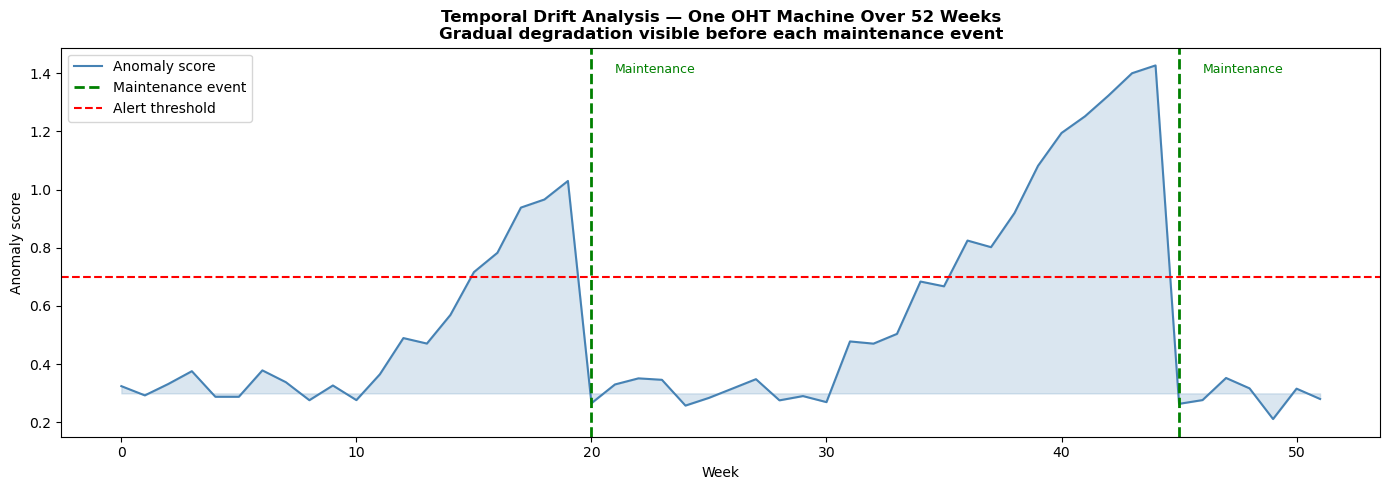

Key observations:
  Weeks 10-20: score drifts from 0.3 to ~1.1 before maintenance
  Week 20:     maintenance resets machine to healthy baseline
  Weeks 30-45: second degradation cycle begins
  Week 45:     second maintenance event


In [46]:
# Strategy 1 — Demonstrate maintenance log validation
# Simulate anomaly scores over time with gradual degradation

np.random.seed(42)
n_weeks = 52  # one year of weekly recordings

# Simulate one machine's anomaly score over 52 weeks
# Maintenance happens at week 20 and week 45
# Gradual degradation builds up before each maintenance

weeks = np.arange(n_weeks)

# Base score with some noise
base_score = 0.3 + np.random.normal(0, 0.05, n_weeks)

# Add gradual degradation before maintenance events
# Weeks 10-20: degrading before first maintenance
base_score[10:20] += np.linspace(0, 0.8, 10)
# Weeks 30-45: degrading before second maintenance  
base_score[30:45] += np.linspace(0, 1.2, 15)

# Reset after maintenance (machine is healthy again)
base_score[20:30] = 0.3 + np.random.normal(0, 0.05, 10)

maintenance_weeks = [20, 45]

plt.figure(figsize=(14, 5))
plt.plot(weeks, base_score, color='steelblue', linewidth=1.5, label='Anomaly score')
plt.fill_between(weeks, base_score, 0.3, alpha=0.2, color='steelblue')

for mw in maintenance_weeks:
    plt.axvline(x=mw, color='green', linestyle='--', 
                linewidth=2, label='Maintenance event' if mw == 20 else '')
    plt.annotate('Maintenance', xy=(mw, 1.3),
                xytext=(mw+1, 1.4), fontsize=9, color='green')

plt.axhline(y=0.7, color='red', linestyle='--', 
            linewidth=1.5, label='Alert threshold')
plt.xlabel('Week')
plt.ylabel('Anomaly score')
plt.title('Temporal Drift Analysis — One OHT Machine Over 52 Weeks\n'
          'Gradual degradation visible before each maintenance event',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('temporal_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print(f'  Weeks 10-20: score drifts from 0.3 to ~1.1 before maintenance')
print(f'  Week 20:     maintenance resets machine to healthy baseline')
print(f'  Weeks 30-45: second degradation cycle begins')
print(f'  Week 45:     second maintenance event')

In [47]:
print("="*55)
print("PIPELINE SUMMARY")
print("="*55)
print(f"Audio features per recording    : 26 (13 MFCC means + stds)")
print(f"Multimodal features added       : 3  (velocity, acceleration, maintenance)")
print(f"Total features per recording    : 29")
print(f"")
print(f"Isolation Forest results:")
print(f"  Normal correctly identified   : 38/40")
print(f"  Anomalies caught              : 10/10")
print(f"")
print(f"Autoencoder (audio only):")
print(f"  Normal correctly identified   : 40/40")
print(f"  Anomalies caught              : 10/10")
print(f"  Separation ratio              : ~97,000x")
print(f"")
print(f"Autoencoder (multimodal):")
print(f"  Normal correctly identified   : 40/40")
print(f"  Anomalies caught              : 10/10")
print(f"  Separation ratio              : ~235,000x")
print(f"  Improvement over audio only   : 2.4x")
print("="*55)

PIPELINE SUMMARY
Audio features per recording    : 26 (13 MFCC means + stds)
Multimodal features added       : 3  (velocity, acceleration, maintenance)
Total features per recording    : 29

Isolation Forest results:
  Normal correctly identified   : 38/40
  Anomalies caught              : 10/10

Autoencoder (audio only):
  Normal correctly identified   : 40/40
  Anomalies caught              : 10/10
  Separation ratio              : ~97,000x

Autoencoder (multimodal):
  Normal correctly identified   : 40/40
  Anomalies caught              : 10/10
  Separation ratio              : ~235,000x
  Improvement over audio only   : 2.4x
